In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import ast
import torch
import seaborn as sns
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_score, recall_score, confusion_matrix
from tabulate import tabulate
import os
from collections import Counter
from sklearn.preprocessing import StandardScaler

In [2]:
import numpy as np
from scipy.signal import find_peaks

def pan_tompkins_r_peak_detection(ecg_signal, fs=100):
    """
    Apply the Pan-Tompkins algorithm for R-peak detection in ECG signal.
    """
    # Step 1: Differentiation
    diff_ecg = np.diff(ecg_signal)
    
    # Step 2: Squaring
    squared_ecg = diff_ecg ** 2
    
    # Step 3: Moving Window Integration (MWI)
    window_size = int(0.150 * fs)
    mwi_ecg = np.convolve(squared_ecg, np.ones(window_size)/window_size, mode='same')
    
    # Step 4: Thresholding
    threshold = 0.6 * np.max(mwi_ecg)
    # Ensure minimum distance between peaks (0.6s * fs)
    r_peaks, _ = find_peaks(mwi_ecg, height=threshold, distance=int(0.6 * fs))
    
    return r_peaks

def extract_heartbeats(X, max_len=20, window_len=100, fs=100):
    """
    Extract heartbeats using Pan-Tompkins. If fewer beats are detected than max_beats,
    existing beats are repeated (cyclically) instead of padding with zeros.
    """
    
    B, C, L = X.shape  # (Batch, Channels, Length)
    
    # --- Pass 1: Determine Max Beats ---
    max_beats = max_len
    all_r_peaks = [] # Cache r_peaks to avoid re-calculating in Pass 2
    
    for i in range(B):
        # Extract Lead II (index 1) for detection
        lead_ii = X[i, 1, :]
        r_peaks = pan_tompkins_r_peak_detection(lead_ii, fs)
        all_r_peaks.append(r_peaks)
        max_beats = max(max_beats, len(r_peaks))
    
    # Safety fallback if no peaks detected in entire batch
    if max_beats == 0:
        max_beats = 1 

    # Initialize output array
    heartbeats_array = np.zeros((B, max_beats, C, window_len))
    
    window_ratio = 0.4
    
    # --- Pass 2: Extract and Pad ---
    for i in range(B):
        r_peaks = all_r_peaks[i]
        beats = []
        
        # 1. Extract valid beats
        for peak in r_peaks:
            start = max(peak - int(window_len * window_ratio), 0)
            end = min(peak + int(window_len * (1 - window_ratio)), L)
            heartbeat = X[i, :, start:end]
            
            # Skip incomplete windows at edges
            if heartbeat.shape[1] < window_len:
                continue
            
            beats.append(heartbeat)
        
        # 2. Handle Padding (Repetition Logic)
        num_detected = len(beats)
        
        if num_detected == 0:
            # Edge Case: No beats found in this specific sample.
            # We must pad with zeros or noise to maintain shape, 
            # though this is rare with good data.
            for j in range(max_beats):
                beats.append(np.zeros((C, window_len)))
        
        elif num_detected < max_beats:
            # Main Logic: Repeat existing beats cyclically
            # If we have [A, B] and need 5 total, we append A, B, A -> [A, B, A, B, A]
            needed = max_beats - num_detected
            for j in range(needed):
                # Use modulo to cycle through valid beats
                beat_to_repeat = beats[j % num_detected]
                beats.append(beat_to_repeat)
        
        # If we somehow have too many (rare due to Pass 1 logic, but possible if edges were skipped), trim
        beats = beats[:max_beats]
        
        heartbeats_array[i] = np.array(beats)
    
    # Transpose to (B, C, Beats, Time)
    return heartbeats_array.transpose(0, 2, 1, 3)

In [3]:
import scipy.signal as signal
def filter_signal(signal_data, axis=0, fs=100, lowcut=0.5, highcut=45.0):
        nyquist = 0.5 * fs
        low = lowcut / nyquist
        high = highcut / nyquist
        b, a = signal.butter(4, [low, high], btype='band')
        return signal.filtfilt(b, a, signal_data, axis=axis)

def normalize_min_max(arr, epsilon=1e-8):
    # Normalize the last dimension (axis=-1) using min-max normalization
    min_vals = arr.min(axis=-1, keepdims=True)
    max_vals = arr.max(axis=-1, keepdims=True)
    
    # Add epsilon to prevent division by zero for flat/padded signals
    normalized_arr = (arr - min_vals) / (max_vals - min_vals + epsilon)
    
    # Optional: Fill any remaining NaNs with 0 just in case
    normalized_arr = np.nan_to_num(normalized_arr)
    
    return normalized_arr

In [4]:
import pandas as pd
import numpy as np
import os
from tabulate import tabulate

# 1. Define the refined dictionary (Only high-performance classes)
superclass_dict = {
    'NORM': ['NORM'],
    'CD':   ['LAFB/LPFB', 'IRBBB', 'ILBBB', 'CLBBB', 'CRBBB', '_AVB', 'IVCB'],
    'HYP':  ['LVH', 'RVH', 'LAO/LAE', 'RAO/RAE', 'SEHYP'],
    'MI':   ['AMI', 'IMI', 'LMI', 'PMI', 'ISCA', 'ISCI'],
    'STTC': ['ISC_', 'STTC', 'NST_']
}

# Flatten the list to get valid column names in order
valid_subclasses = [item for sublist in superclass_dict.values() for item in sublist]
print(f"Selected {len(valid_subclasses)} subclasses: {valid_subclasses}")

path_load = '../../source/data_source_sub'

# --- Helper to load and filter labels ---
def load_and_filter_labels(csv_path, valid_cols):
    df = pd.read_csv(csv_path)
    # Check which valid columns actually exist in the CSV
    existing_cols = [c for c in valid_cols if c in df.columns]
    
    # Select only valid columns
    df_filtered = df[existing_cols]
    return df_filtered.to_numpy(dtype=np.float32)

# --- Load Data ---

# 1. Train
X_train = np.load(os.path.join(path_load, 'Y_train.npy'))
X_train = filter_signal(X_train, axis=1, fs=100, lowcut=0.5, highcut=45.0).transpose(0, 2, 1)
heartbeats_train = normalize_min_max(extract_heartbeats(X_train))

y_train_df = pd.read_csv(os.path.join(path_load, 'Z_train.csv')).drop(columns=['ecg_id'])
y_train = y_train_df.to_numpy(dtype=np.float32)

# FILTER Z (Subclass)
z_train = load_and_filter_labels(os.path.join(path_load, 'T_train.csv'), valid_subclasses)


# 2. Test
X_test = np.load(os.path.join(path_load, 'Y_test.npy'))
X_test = filter_signal(X_test, axis=1, fs=100, lowcut=0.5, highcut=45.0).transpose(0, 2, 1)
heartbeats_test = normalize_min_max(extract_heartbeats(X_test))

y_test_df = pd.read_csv(os.path.join(path_load, 'Z_test.csv')).drop(columns=['ecg_id'])
y_test = y_test_df.to_numpy(dtype=np.float32)

# FILTER Z (Subclass)
z_test = load_and_filter_labels(os.path.join(path_load, 'T_test.csv'), valid_subclasses)


# 3. Validation
X_val = np.load(os.path.join(path_load, 'Y_valid.npy'))
X_val = filter_signal(X_val, axis=1, fs=100, lowcut=0.5, highcut=45.0).transpose(0, 2, 1)
heartbeats_val = normalize_min_max(extract_heartbeats(X_val))

y_val_df = pd.read_csv(os.path.join(path_load, 'Z_valid.csv')).drop(columns=['ecg_id'])
y_val = y_val_df.to_numpy(dtype=np.float32)

# FILTER Z (Subclass)
z_val = load_and_filter_labels(os.path.join(path_load, 'T_valid.csv'), valid_subclasses)


# --- Print New Shapes ---
table = [
    ["X_train", X_train.shape],
    ["Heartbeats train", heartbeats_train.shape],
    ["y_train", y_train.shape],
    ["z_train (Filtered)", z_train.shape], # Should have fewer columns (e.g., 10 instead of 23)
    ["X_test", X_test.shape],
    ["Heartbeats test", heartbeats_test.shape],
    ["y_test", y_test.shape],
    ["z_test (Filtered)", z_test.shape],
    ["X_val", X_val.shape],
    ["Heartbeats val", heartbeats_val.shape],
    ["y_val", y_val.shape],
    ["z_val (Filtered)", z_val.shape],
]

print(tabulate(table, headers=["Dataset", "Shape"], tablefmt="grid"))

Selected 22 subclasses: ['NORM', 'LAFB/LPFB', 'IRBBB', 'ILBBB', 'CLBBB', 'CRBBB', '_AVB', 'IVCB', 'LVH', 'RVH', 'LAO/LAE', 'RAO/RAE', 'SEHYP', 'AMI', 'IMI', 'LMI', 'PMI', 'ISCA', 'ISCI', 'ISC_', 'STTC', 'NST_']
+--------------------+----------------------+
| Dataset            | Shape                |
+====================+======================+
| X_train            | (17441, 12, 1000)    |
+--------------------+----------------------+
| Heartbeats train   | (17441, 12, 20, 100) |
+--------------------+----------------------+
| y_train            | (17441, 5)           |
+--------------------+----------------------+
| z_train (Filtered) | (17441, 22)          |
+--------------------+----------------------+
| X_test             | (2203, 12, 1000)     |
+--------------------+----------------------+
| Heartbeats test    | (2203, 12, 20, 100)  |
+--------------------+----------------------+
| y_test             | (2203, 5)            |
+--------------------+----------------------+
| z_tes

In [5]:
columns_of_csv = pd.read_csv(os.path.join(path_load, 'Z_train.csv'))
label_map = {label: i for i, label in enumerate(columns_of_csv.columns[1:])}
print(label_map)

columns_of_csv = pd.read_csv(os.path.join(path_load, 'T_train.csv'))
label_map_sub = {label: i for i, label in enumerate(columns_of_csv.columns[1:])}
print(label_map_sub)

superclass_dict = {
    'NORM': ['NORM'],
    'CD': ['LAFB/LPFB', 'IRBBB', 'ILBBB', 'CLBBB', 'CRBBB', '_AVB', 'IVCB'],
    'HYP': ['LVH', 'RVH', 'LAO/LAE', 'RAO/RAE', 'SEHYP'],
    'MI': ['AMI', 'IMI', 'LMI', 'PMI', 'ISCA', 'ISCI'],
    'STTC': ['ISC_', 'STTC', 'NST_']
}

{'NORM': 0, 'CD': 1, 'HYP': 2, 'MI': 3, 'STTC': 4}
{'NORM': 0, 'LAFB/LPFB': 1, 'IRBBB': 2, 'ILBBB': 3, 'CLBBB': 4, 'CRBBB': 5, '_AVB': 6, 'IVCB': 7, 'WPW': 8, 'LVH': 9, 'RVH': 10, 'LAO/LAE': 11, 'RAO/RAE': 12, 'SEHYP': 13, 'AMI': 14, 'IMI': 15, 'LMI': 16, 'PMI': 17, 'ISCA': 18, 'ISCI': 19, 'ISC_': 20, 'STTC': 21, 'NST_': 22}


In [6]:
x_train = torch.from_numpy(heartbeats_train).float()  # float tensor for input
labels_train = torch.from_numpy(y_train).float()  # float tensor for labels
sub_labels_train = torch.from_numpy(z_train).float()

x_val = torch.from_numpy(heartbeats_val).float()
labels_val = torch.from_numpy(y_val).float()
sub_labels_val = torch.from_numpy(z_val).float()

x_test = torch.from_numpy(heartbeats_test).float()
lables_test = torch.from_numpy(y_test).float()
sub_labels_test = torch.from_numpy(z_test).float()

batch_size = 32

train_dataset = TensorDataset(x_train, labels_train, sub_labels_train)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

val_dataset = TensorDataset(x_val, labels_val, sub_labels_val)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

test = TensorDataset(x_test, lables_test, sub_labels_test)
test_loader = DataLoader(test, batch_size=batch_size, shuffle=False)

In [13]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchinfo import summary
import math

# ---------------------------------------------------------
# 0. NEW: Robust Components (Cosine Classifier)
# ---------------------------------------------------------
class CosineLinear(nn.Module):
    """
    Replaces nn.Linear for the final classification layer.
    It normalizes both the input features and the weight vectors.
    This ensures predictions are based on angular similarity, preventing 
    majority classes from dominating via weight magnitude.
    """
    def __init__(self, in_features, out_features, sigma=30.0):
        super().__init__()
        self.in_features = in_features
        self.out_features = out_features
        self.weight = nn.Parameter(torch.Tensor(out_features, in_features))
        self.sigma = sigma  # Scale factor (temperature), trainable or fixed
        self.reset_parameters()

    def reset_parameters(self):
        nn.init.kaiming_uniform_(self.weight, a=math.sqrt(5))

    def forward(self, x):
        # Normalize Input and Weights
        cosine = F.linear(F.normalize(x, p=2, dim=1), F.normalize(self.weight, p=2, dim=1))
        return cosine * self.sigma

# ---------------------------------------------------------
# 1. 1D ECA Attention (Unchanged)
# ---------------------------------------------------------
class ECAAttention1D(nn.Module):
    def __init__(self, kernel_size=3):
        super().__init__()
        self.avg_pool = nn.AdaptiveAvgPool1d(1)
        self.conv = nn.Conv1d(1, 1, kernel_size=kernel_size, padding=(kernel_size - 1) // 2, bias=False)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        y = self.avg_pool(x).transpose(-1, -2)
        y = self.conv(y)
        y = self.sigmoid(y.transpose(-1, -2))
        return x * y

# ---------------------------------------------------------
# 2. Robust Block 1D (Unchanged)
# ---------------------------------------------------------
class RobustBlock1D(nn.Module):
    def __init__(self, dim, layer_scale_init_value=1e-6):
        super().__init__()
        self.dwconv = nn.Conv1d(dim, dim, kernel_size=7, padding=3, groups=dim, bias=False)
        self.bn = nn.BatchNorm1d(dim)
        self.pwconv1 = nn.Linear(dim, 4 * dim) 
        self.act = nn.GELU()
        self.pwconv2 = nn.Linear(4 * dim, dim)
        self.gamma = nn.Parameter(layer_scale_init_value * torch.ones((dim)), 
                                    requires_grad=True) if layer_scale_init_value > 0 else None
        self.eca = ECAAttention1D(kernel_size=5)

    def forward(self, x):
        input = x
        x = self.dwconv(x)
        x = self.bn(x)
        x = x.permute(0, 2, 1)
        x = self.pwconv1(x)
        x = self.act(x)
        x = self.pwconv2(x)
        if self.gamma is not None:
            x = self.gamma * x
        x = x.permute(0, 2, 1)
        x = self.eca(x)
        x = input + x
        return x

# ---------------------------------------------------------
# 3. Attention Pooling (Unchanged)
# ---------------------------------------------------------
class AttentionPooling(nn.Module):
    def __init__(self, in_dim):
        super().__init__()
        self.attention = nn.Sequential(
            nn.Linear(in_dim, in_dim // 2),
            nn.Tanh(),
            nn.Linear(in_dim // 2, 1)
        )

    def forward(self, x):
        scores = self.attention(x)
        weights = F.softmax(scores, dim=1)
        weighted_features = torch.sum(x * weights, dim=1)
        return weighted_features, weights

# ---------------------------------------------------------
# 4. Subclass Adapter Block (Unchanged)
# ---------------------------------------------------------
class SubclassAdapter(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.norm = nn.LayerNorm(dim)
        self.fc1 = nn.Linear(dim, dim * 2)
        self.act = nn.GELU()
        self.dropout = nn.Dropout(0.2)
        self.fc2 = nn.Linear(dim * 2, dim)
        
    def forward(self, x):
        identity = x
        out = self.norm(x)
        out = self.fc1(out)
        out = self.act(out)
        out = self.dropout(out)
        out = self.fc2(out)
        return identity + out 

# ---------------------------------------------------------
# 5. Main Network (ROBUST VERSION)
# ---------------------------------------------------------
class BagOfBeatsECGNet(nn.Module):
    def __init__(self, num_superclasses=5, num_subclasses=23, in_channels=12, 
                 dims=[32, 64, 128], depths=[2, 2, 2], use_cosine_head=True):
        super().__init__()
        
        # --- 1. Beat Feature Extractor ---
        self.stem = nn.Sequential(
            nn.Conv1d(in_channels, dims[0], kernel_size=4, stride=2, padding=1),
            nn.BatchNorm1d(dims[0]),
            nn.GELU()
        )
        
        self.stages = nn.ModuleList()
        curr_dim = dims[0]
        for i in range(3):
            if i > 0:
                downsample = nn.Sequential(
                    nn.BatchNorm1d(curr_dim),
                    nn.Conv1d(curr_dim, dims[i], kernel_size=2, stride=2)
                )
                curr_dim = dims[i]
            else:
                downsample = nn.Identity()
            blocks = nn.Sequential(*[RobustBlock1D(dim=curr_dim) for _ in range(depths[i])])
            self.stages.append(nn.Sequential(downsample, blocks))
            
        self.global_pool_1d = nn.AdaptiveAvgPool1d(1)
        
        # --- 2. Beat Aggregator ---
        last_dim = dims[-1]
        self.beat_attention = AttentionPooling(last_dim)
        
        # --- 3. Superclass Head ---
        # Note: We keep superclass head standard (Linear) as superclasses 
        # are usually more balanced than subclasses.
        self.fc_superclass = nn.Sequential(
            nn.LayerNorm(last_dim),
            nn.Linear(last_dim, last_dim),
            nn.GELU(),
            nn.Linear(last_dim, num_superclasses)
        )
        
        # --- 4. Subclass Path (Robust Fusion) ---
        self.subclass_adapter = SubclassAdapter(last_dim)
        
        # B: Advanced Gating Network
        # MODIFICATION: Added normalization (Tanh) to input of gate
        # to prevent magnitude bias from imbalanced superclasses
        self.gate_net = nn.Sequential(
            nn.Linear(num_superclasses, last_dim // 2),
            nn.ReLU(),
            nn.Linear(last_dim // 2, last_dim),
            nn.Sigmoid()
        )
        
        # C: Subclass Head
        # MODIFICATION: Option to use CosineLinear for imbalanced subclasses
        self.fc_subclass_pre = nn.Sequential(
            nn.LayerNorm(last_dim),
            nn.Linear(last_dim, last_dim),
            nn.GELU(),
            nn.Dropout(0.3) # Increased Dropout slightly for robustness
        )
        
        if use_cosine_head:
            self.fc_subclass_out = CosineLinear(last_dim, num_subclasses)
        else:
            self.fc_subclass_out = nn.Linear(last_dim, num_subclasses)

    def forward(self, x):
        B, C, Beats, T = x.size()
        
        # 1. Fold & Extract
        x = x.permute(0, 2, 1, 3).contiguous().view(B * Beats, C, T)
        x = self.stem(x)
        for stage in self.stages:
            x = stage(x)
        x = self.global_pool_1d(x).flatten(1)
        x = x.view(B, Beats, -1)
        
        # 2. Aggregation
        global_features, _ = self.beat_attention(x)
        
        # 3. Superclass Prediction
        superclass_logits = self.fc_superclass(global_features)
        
        # 4. Robust Fusion
        subclass_features = self.subclass_adapter(global_features)
        
        # MODIFICATION: Tanh to normalize logits range before Gating
        # This prevents the gate from being dominated by high-magnitude 
        # logits of majority superclasses.
        gate_input = torch.tanh(superclass_logits) 
        gate = self.gate_net(gate_input)
        
        gated_features = subclass_features * gate
        
        # 5. Subclass Prediction
        subclass_emb = self.fc_subclass_pre(gated_features)
        subclass_logits = self.fc_subclass_out(subclass_emb)
        
        return superclass_logits, subclass_logits

# ---------------------------------------------------------
# 6. Focal Loss (Helper for Training)
# ---------------------------------------------------------
class FocalLoss(nn.Module):
    def __init__(self, alpha=1, gamma=2, reduction='mean'):
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, inputs, targets):
        ce_loss = F.cross_entropy(inputs, targets, reduction='none')
        pt = torch.exp(-ce_loss)
        focal_loss = self.alpha * (1 - pt) ** self.gamma * ce_loss
        
        if self.reduction == 'mean':
            return focal_loss.mean()
        elif self.reduction == 'sum':
            return focal_loss.sum()
        else:
            return focal_loss

# ---------------------------------------------------------
# Verification
# ---------------------------------------------------------
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = BagOfBeatsECGNet(
    num_superclasses=5, 
    num_subclasses=22, 
    in_channels=12,
    use_cosine_head=True # Enable Robust Head
).to(device)

print("Model Initialized with Cosine Head for Imbalance Robustness")

# Check input size handling
summary(model, 
        input_size=(1, 12, 20, 100), 
        col_names=["input_size", "output_size", "num_params", "mult_adds"],
        col_width=20,
        row_settings=["var_names"]
)

Model Initialized with Cosine Head for Imbalance Robustness


Layer (type (var_name))                                      Input Shape          Output Shape         Param #              Mult-Adds
BagOfBeatsECGNet (BagOfBeatsECGNet)                          [1, 12, 20, 100]     [1, 5]               --                   --
├─Sequential (stem)                                          [20, 12, 100]        [20, 32, 50]         --                   --
│    └─Conv1d (0)                                            [20, 12, 100]        [20, 32, 50]         1,568                1,568,000
│    └─BatchNorm1d (1)                                       [20, 32, 50]         [20, 32, 50]         64                   1,280
│    └─GELU (2)                                              [20, 32, 50]         [20, 32, 50]         --                   --
├─ModuleList (stages)                                        --                   --                   --                   --
│    └─Sequential (0)                                        [20, 32, 50]         [20, 32, 50]

In [14]:
def multi_task_loss(output_main, target_main, output_aux, target_aux, model):
    criterion = nn.BCEWithLogitsLoss()
    loss_main = criterion(output_main, target_main)
    loss_aux = criterion(output_aux, target_aux)

    #weighted_loss = (main_weight * weights[0] * loss_main) + (aux_weight * weights[1] * loss_aux)
    #weighted_loss = (lambda_weight * loss_main) + ((1-lambda_weight) * loss_aux)
    weighted_loss = (loss_main) + (loss_aux)

    return weighted_loss, loss_main.item(), loss_aux.item()

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.BCEWithLogitsLoss()

In [15]:
from sklearn.metrics import accuracy_score, f1_score
import numpy as np
import torch
import copy

# 4. Training loop
num_epochs = 30
best_val_f1 = 0.0  # CHANGED: Track best F1 instead of loss
best_model_wts = None  # To save the best model

for epoch in range(num_epochs):
    model.train()
    train_loss = 0.0
    train_main_loss = 0.0
    train_aux_loss = 0.0
    
    # Accumulators for training metrics
    train_preds_main, train_targets_main = [], []
    train_preds_aux, train_targets_aux = [], []

    for inputs, targets, sub_targets in train_loader:
        inputs, targets, sub_targets = inputs.to(device), targets.to(device), sub_targets.to(device)

        optimizer.zero_grad()
        outputs_main, outputs_aux = model(inputs)  # CNN expects (batch, channels, seq_len)
        loss, train_lm, train_la = multi_task_loss(outputs_main, targets, outputs_aux, sub_targets, model)
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * inputs.size(0)
        train_main_loss += train_lm * inputs.size(0)
        train_aux_loss += train_la * inputs.size(0)

        # --- Collect Predictions for Metrics ---
        with torch.no_grad():
            # Apply Sigmoid and Threshold
            preds_m = (torch.sigmoid(outputs_main) > 0.5).int()
            preds_a = (torch.sigmoid(outputs_aux) > 0.5).int()
            
            # Move to CPU and append
            train_preds_main.append(preds_m.cpu().numpy())
            train_targets_main.append(targets.cpu().numpy())
            train_preds_aux.append(preds_a.cpu().numpy())
            train_targets_aux.append(sub_targets.cpu().numpy())

    # Average Losses
    train_loss /= len(train_loader.dataset)
    train_main_loss /= len(train_loader.dataset)
    train_aux_loss /= len(train_loader.dataset)

    # --- Calculate Training Metrics ---
    train_preds_main = np.vstack(train_preds_main)
    train_targets_main = np.vstack(train_targets_main)
    
    train_acc = accuracy_score(train_targets_main, train_preds_main)
    train_f1 = f1_score(train_targets_main, train_preds_main, average='macro', zero_division=0)

    # Validation
    model.eval()
    val_loss = 0.0
    val_main_loss = 0.0
    val_aux_loss = 0.0
    
    # Accumulators for validation metrics
    val_preds_main, val_targets_main = [], []

    with torch.no_grad():
        for inputs, targets, sub_targets in val_loader:
            inputs, targets, sub_targets = inputs.to(device), targets.to(device), sub_targets.to(device)
            
            outputs_main, outputs_aux = model(inputs)  # CNN expects (batch, channels, seq_len)
            loss_, val_lm, val_la = multi_task_loss(outputs_main, targets, outputs_aux, sub_targets, model)
            val_loss += loss_.item() * inputs.size(0)
            val_main_loss += val_lm * inputs.size(0)
            val_aux_loss += val_la * inputs.size(0)
            
            # --- Collect Predictions for Metrics ---
            preds_m = (torch.sigmoid(outputs_main) > 0.5).int()
            val_preds_main.append(preds_m.cpu().numpy())
            val_targets_main.append(targets.cpu().numpy())

    # Average Losses
    val_loss /= len(val_loader.dataset)
    val_main_loss /= len(val_loader.dataset)
    val_aux_loss /= len(val_loader.dataset)
    
    # --- Calculate Validation Metrics ---
    val_preds_main = np.vstack(val_preds_main)
    val_targets_main = np.vstack(val_targets_main)
    
    val_acc = accuracy_score(val_targets_main, val_preds_main)
    val_f1 = f1_score(val_targets_main, val_preds_main, average='macro', zero_division=0)

    # Print with color and progress bar
    epoch_str = f"\033[1;36mEpoch {epoch+1}/{num_epochs}\033[0m"
    bar_len = 30
    filled_len = int(round(bar_len * (epoch+1) / float(num_epochs)))
    bar = '=' * filled_len + '-' * (bar_len - filled_len)
    
    print(f"{epoch_str} [{bar}]")
    print(f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")
    print(f"Train Acc:  {train_acc:.4f} | Val Acc:  {val_acc:.4f}")
    print(f"Train F1:   {train_f1:.4f} | Val F1:   {val_f1:.4f}")
    
    # CHANGED: Save based on best F1 Score
    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        print(f"\033[1;32mFound best save with Val F1: {val_f1:.4f}\033[0m")
        best_model_wts = copy.deepcopy(model.state_dict())  # Save deep copy to be safe
        
# --- Test Phase ---
if best_model_wts is not None:
    model.load_state_dict(best_model_wts)
    
model.eval()
test_loss = 0.0
test_preds_main, test_targets_main = [], []

with torch.no_grad():
    for inputs, targets, sub_targets in test_loader:
        inputs, targets, sub_targets = inputs.to(device), targets.to(device), sub_targets.to(device)
        
        outputs_main, outputs_aux = model(inputs)
        loss, test_lm, test_la = multi_task_loss(outputs_main, targets, outputs_aux, sub_targets, model)
        test_loss += loss.item() * inputs.size(0)
        
        # --- Collect Predictions ---
        preds_m = (torch.sigmoid(outputs_main) > 0.5).int()
        test_preds_main.append(preds_m.cpu().numpy())
        test_targets_main.append(targets.cpu().numpy())

test_loss /= len(test_loader.dataset)

# --- Calculate Test Metrics ---
test_preds_main = np.vstack(test_preds_main)
test_targets_main = np.vstack(test_targets_main)

test_acc = accuracy_score(test_targets_main, test_preds_main)
test_f1 = f1_score(test_targets_main, test_preds_main, average='macro', zero_division=0)

print("-" * 50)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Acc:  {test_acc:.4f}")
print(f"Test F1:   {test_f1:.4f}")
print("-" * 50)

Epoch 1/30 [=-----------------------------]
Train Loss: 0.5811 | Val Loss: 0.5312
Train Acc:  0.4276 | Val Acc:  0.5253
Train F1:   0.4500 | Val F1:   0.5265
Found best save with Val F1: 0.5265
Epoch 2/30 [==----------------------------]
Train Loss: 0.4736 | Val Loss: 0.4796
Train Acc:  0.5402 | Val Acc:  0.5321
Train F1:   0.5909 | Val F1:   0.5528
Found best save with Val F1: 0.5528
Epoch 3/30 [===---------------------------]
Train Loss: 0.4467 | Val Loss: 0.4530
Train Acc:  0.5594 | Val Acc:  0.5568
Train F1:   0.6175 | Val F1:   0.6337
Found best save with Val F1: 0.6337
Epoch 4/30 [====--------------------------]
Train Loss: 0.4277 | Val Loss: 0.4564
Train Acc:  0.5785 | Val Acc:  0.5727
Train F1:   0.6413 | Val F1:   0.6359
Found best save with Val F1: 0.6359
Epoch 5/30 [=====-------------------------]
Train Loss: 0.4153 | Val Loss: 0.4701
Train Acc:  0.5874 | Val Acc:  0.5326
Train F1:   0.6551 | Val F1:   0.6138
Epoch 6/30 [======------------------------]
Train Loss: 0.4085 | V

In [16]:
from sklearn.metrics import precision_score, recall_score, confusion_matrix
import numpy as np
from tabulate import tabulate

def performance_evaluation(model, dataset, dataset_name, label_map, label_map_sub):
    
    all_targets = []
    all_preds = []
    all_sub_targets = []
    all_sub_preds = []

    model.eval()
    with torch.no_grad():
        for inputs, targets, sub_targets in dataset:
            inputs, targets, sub_targets = inputs.to(device), targets.to(device), sub_targets.to(device)
            outputs_main, output_aux = model(inputs)
            
            probs = torch.sigmoid(outputs_main)
            preds = (probs > 0.5).int()
            
            probs_sub = torch.sigmoid(output_aux)
            preds_sub = (probs_sub > 0.5).int()

            all_targets.append(targets.cpu().numpy())
            all_preds.append(preds.cpu().numpy())
            all_sub_targets.append(sub_targets.cpu().numpy())
            all_sub_preds.append(preds_sub.cpu().numpy())

    all_targets = np.vstack(all_targets)
    all_preds = np.vstack(all_preds)
    all_sub_targets = np.vstack(all_sub_targets)
    all_sub_preds = np.vstack(all_sub_preds)
    
    # --- SAFETY CHECK ---
    if all_targets.shape[1] != len(label_map):
        print(f"WARNING: Main output shape {all_targets.shape[1]} != Label Map length {len(label_map)}")
        # Fallback to prevent crash
        loop_limit_main = min(all_targets.shape[1], len(label_map))
    else:
        loop_limit_main = len(label_map)
        
    if all_sub_targets.shape[1] != len(label_map_sub):
        print(f"WARNING: Subclass output shape {all_sub_targets.shape[1]} != Label Map length {len(label_map_sub)}")
        # Fallback to prevent crash
        loop_limit_sub = min(all_sub_targets.shape[1], len(label_map_sub))
    else:
        loop_limit_sub = len(label_map_sub)

    # Prepare table data
    table_data = []
    table_sub_data = []
    headers = ["Class", "Precision", "Recall (Sensitivity)", "Specificity", "F1-Score", "TN", "FP", "FN", "TP"]

    # --- Main Class Loop ---
    for i in range(loop_limit_main):
        key = list(label_map.keys())[i] # Get name safely
        y_true = all_targets[:, i]
        y_pred = all_preds[:, i]

        precision = precision_score(y_true, y_pred, zero_division=0)
        recall = recall_score(y_true, y_pred, zero_division=0)
        cm = confusion_matrix(y_true, y_pred)

        if cm.size == 4:
            TN, FP, FN, TP = cm.ravel()
            total = TN + FP + FN + TP
            specificity = TN / (TN + FP) if (TN + FP) > 0 else 0.0
            f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0.0
            TN_str = f"{TN} ({TN/total*100:.1f}%)"
            FP_str = f"{FP} ({FP/total*100:.1f}%)"
            FN_str = f"{FN} ({FN/total*100:.1f}%)"
            TP_str = f"{TP} ({TP/total*100:.1f}%)"
        else:
            TN_str = FP_str = FN_str = TP_str = "0 (0.0%)"
            specificity = 0.0

        table_data.append([key, f"{precision:.4f}", f"{recall:.4f}", f"{specificity:.4f}", f"{f1_score:.4f}", TN_str, FP_str, FN_str, TP_str])

    # --- Subclass Loop ---
    for i in range(loop_limit_sub):
        key = list(label_map_sub.keys())[i] # Get name safely
        y_true = all_sub_targets[:, i]
        y_pred = all_sub_preds[:, i]

        precision = precision_score(y_true, y_pred, zero_division=0)
        recall = recall_score(y_true, y_pred, zero_division=0)
        cm = confusion_matrix(y_true, y_pred)

        if cm.size == 4:
            TN, FP, FN, TP = cm.ravel()
            total = TN + FP + FN + TP
            specificity = TN / (TN + FP) if (TN + FP) > 0 else 0.0
            f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0.0
            TN_str = f"{TN} ({TN/total*100:.1f}%)"
            FP_str = f"{FP} ({FP/total*100:.1f}%)"
            FN_str = f"{FN} ({FN/total*100:.1f}%)"
            TP_str = f"{TP} ({TP/total*100:.1f}%)"
        else:
            TN_str = FP_str = FN_str = TP_str = "0 (0.0%)"
            specificity = 0.0

        table_sub_data.append([key, f"{precision:.4f}", f"{recall:.4f}", f"{specificity:.4f}", f"{f1_score:.4f}", TN_str, FP_str, FN_str, TP_str])

    print(f"\n------------Performance Evaluation Metrics per Class({dataset_name}) -----------\n")
    print(tabulate(table_data, headers=headers, tablefmt="grid"))
    print(tabulate(table_sub_data, headers=headers, tablefmt="grid"))
    
    return all_targets, all_preds

In [17]:
# 1. Generate the correct map for your filtered data
valid_subclasses = [item for sublist in superclass_dict.values() for item in sublist]
new_sub_map = {label: i for i, label in enumerate(valid_subclasses)}

# 2. Pass this map explicitly to the function
targets_train, preds_train = performance_evaluation(model, train_loader, "Train Set", label_map, new_sub_map)
targets_val, preds_val = performance_evaluation(model, val_loader, "Val Set", label_map, new_sub_map)
targets_test, preds_test = performance_evaluation(model, test_loader, "Test Set", label_map, new_sub_map)

f:\dev\ecg-ptb-xl\.venv\Lib\site-packages\sklearn\metrics\_classification.py:534: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(



------------Performance Evaluation Metrics per Class(Train Set) -----------

+---------+-------------+------------------------+---------------+------------+---------------+-------------+-------------+--------------+
| Class   |   Precision |   Recall (Sensitivity) |   Specificity |   F1-Score | TN            | FP          | FN          | TP           |
+=========+=============+========================+===============+============+===============+=============+=============+==============+
| NORM    |      0.9179 |                 0.8714 |        0.9397 |     0.8941 | 9241 (53.0%)  | 593 (3.4%)  | 978 (5.6%)  | 6629 (38.0%) |
+---------+-------------+------------------------+---------------+------------+---------------+-------------+-------------+--------------+
| CD      |      0.8832 |                 0.7464 |        0.9715 |     0.8091 | 13143 (75.4%) | 386 (2.2%)  | 992 (5.7%)  | 2920 (16.7%) |
+---------+-------------+------------------------+---------------+------------+---------

f:\dev\ecg-ptb-xl\.venv\Lib\site-packages\sklearn\metrics\_classification.py:534: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(



------------Performance Evaluation Metrics per Class(Val Set) -----------

+---------+-------------+------------------------+---------------+------------+--------------+------------+------------+-------------+
| Class   |   Precision |   Recall (Sensitivity) |   Specificity |   F1-Score | TN           | FP         | FN         | TP          |
+=========+=============+========================+===============+============+==============+============+============+=============+
| NORM    |      0.8309 |                 0.8422 |        0.8673 |     0.8365 | 1072 (48.9%) | 164 (7.5%) | 151 (6.9%) | 806 (36.8%) |
+---------+-------------+------------------------+---------------+------------+--------------+------------+------------+-------------+
| CD      |      0.7775 |                 0.6539 |        0.9452 |     0.7104 | 1603 (73.1%) | 93 (4.2%)  | 172 (7.8%) | 325 (14.8%) |
+---------+-------------+------------------------+---------------+------------+--------------+------------+-------

f:\dev\ecg-ptb-xl\.venv\Lib\site-packages\sklearn\metrics\_classification.py:534: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


In [18]:
def plot_confusion_matrix_per_class_multi(y_true_list, y_pred_list, class_names=None, set_names=None):
    """
    Plot confusion matrices for multiple sets (e.g., test, val, train) in columns.
    y_true_list, y_pred_list: list of arrays, each for a set.
    set_names: list of names for each set.
    """
    metric_label = ["TN", "FP", "FN", "TP"]
    num_sets = len(y_true_list)
    num_classes = y_true_list[0].shape[1]
    if set_names is None:
        set_names = [f"Set {i+1}" for i in range(num_sets)]
    if class_names is None:
        class_names = [str(i) for i in range(num_classes)]

    for class_idx in range(num_classes):
        fig, axes = plt.subplots(1, num_sets, figsize=(5*num_sets, 4))
        if num_sets == 1:
            axes = [axes]
        for set_idx in range(num_sets):
            y_true = y_true_list[set_idx][:, class_idx]
            y_pred = y_pred_list[set_idx][:, class_idx]
            cm = confusion_matrix(y_true, y_pred)
            total = np.sum(cm)
            if cm.size == 4:
                annot = np.empty_like(cm).astype(str)
                for r in range(2):
                    for c in range(2):
                        count = cm[r, c]
                        row_sum = np.sum(cm[r, :])
                        row_percent = 100 * count / row_sum if row_sum > 0 else 0
                        annot[r, c] = f"{count}\n({metric_label[r*2+c]}:{row_percent:.1f}%)"
            else:
                annot = cm
            sns.heatmap(cm, annot=annot, fmt='', cmap='Blues', cbar=False,
                        xticklabels=['Pred 0', 'Pred 1'], yticklabels=['True 0', 'True 1'],
                        ax=axes[set_idx])
            axes[set_idx].set_title(f"{set_names[set_idx]}")
            axes[set_idx].set_xlabel('Predicted label')
            axes[set_idx].set_ylabel('True label')
        plt.suptitle(f'Confusion Matrix - {class_names[class_idx]}', fontsize=16)
        plt.tight_layout(rect=[0, 0, 1, 0.95])
        plt.show()

confusion_matrix (Test Set)


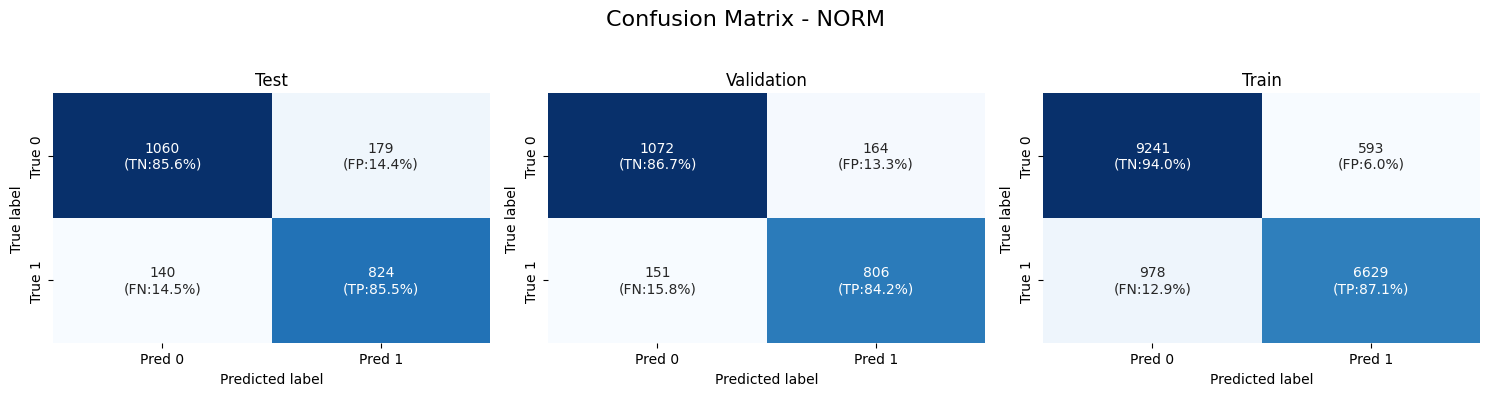

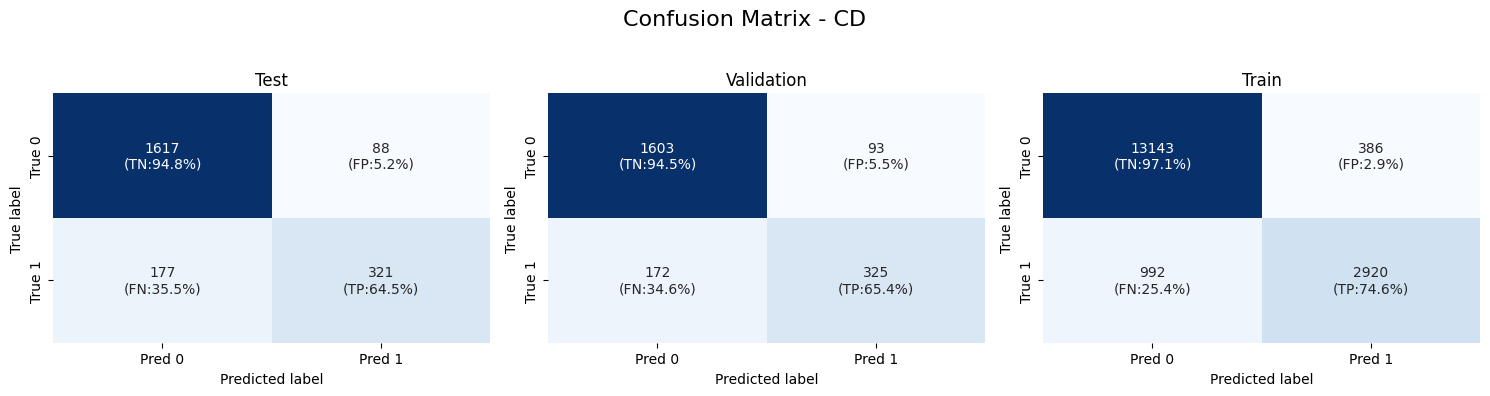

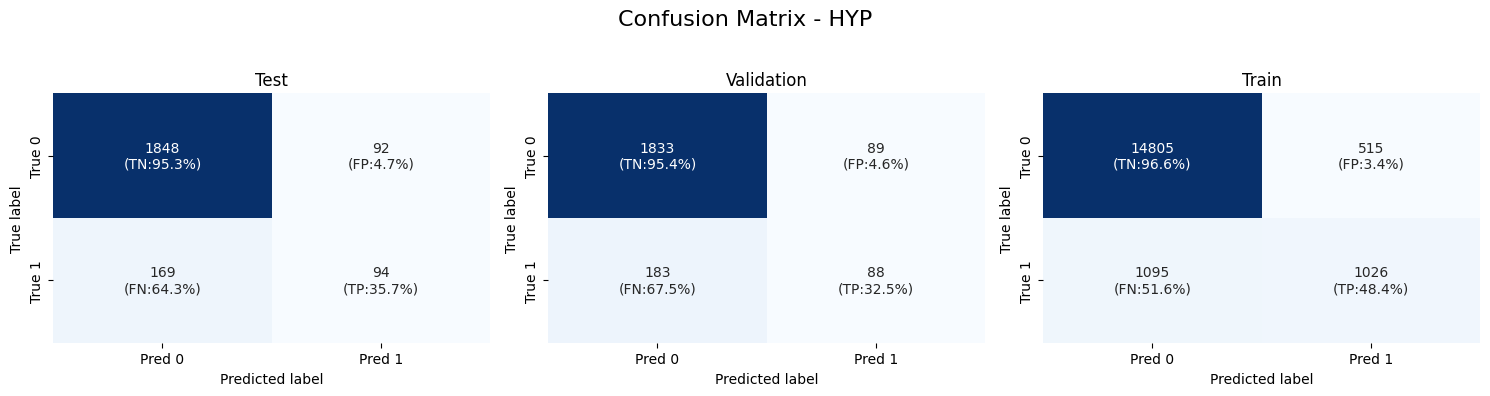

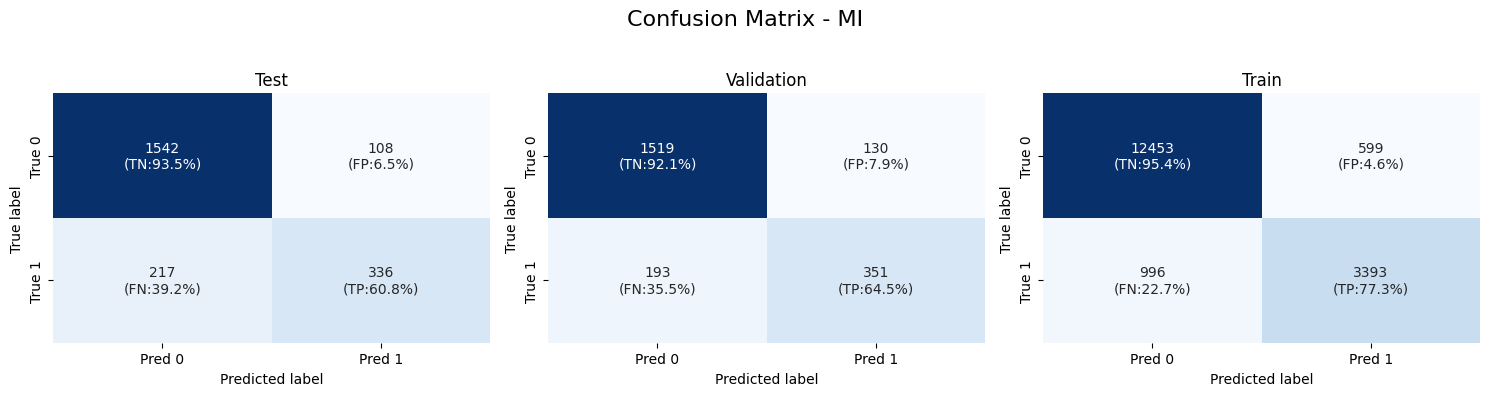

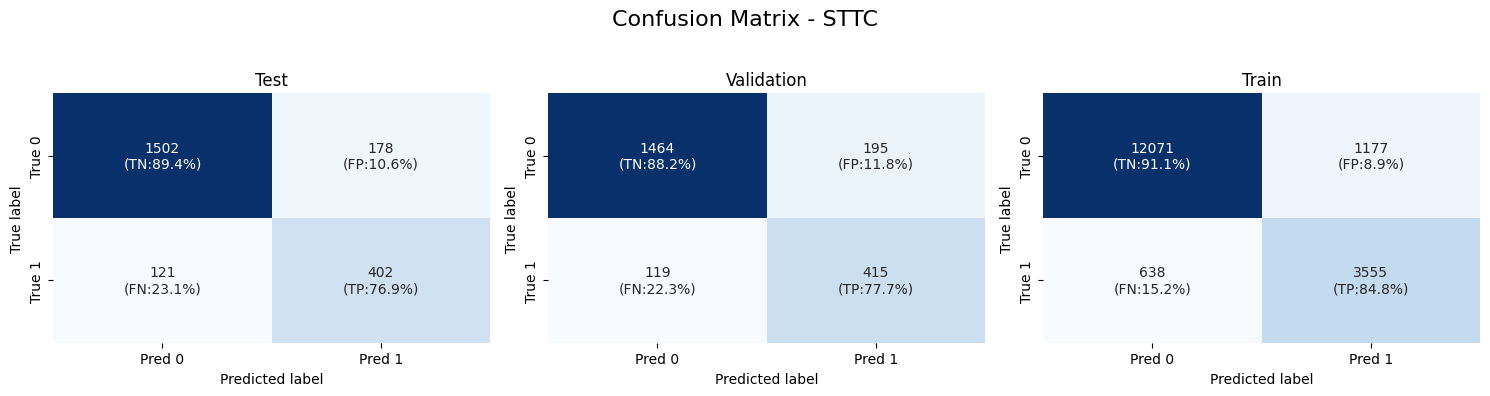

In [19]:
print("confusion_matrix (Test Set)")
#plot_confusion_matrix_per_class(targets_test, preds_test, list(classes_name.keys()))
set_names = ["Test", "Validation", "Train"]
plot_confusion_matrix_per_class_multi(
    [targets_test, targets_val, targets_train],
    [preds_test, preds_val, preds_train],
    class_names=list(label_map.keys()),
    set_names=set_names
)